## 1. Instalación de libreria RAPIDS cuML

In [ ]:
!pip install cudf-cu12 cuml-cu12 --extra-index-url=https://pypi.nvidia.com

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 169.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-cuda-nvcc-cu12
    Found existing installation: nvidia-cuda-nvcc-cu12 12.5.82
    Uninstalling nvidia-cuda-nvcc-cu12-12.5.82:
      Successfully uninstalled nvidia-cuda-nvcc-cu12-12.5.82


## 2. Importar librerias e intentar importar y cargar RAPIDS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Intentar importar RAPIDS
USE_GPU = False
try:
    import cudf
    from cuml.ensemble import RandomForestClassifier as cuRF
    USE_GPU = True
    print("✅ RAPIDS activado (GPU)")
except:
    print("⚠️ RAPIDS no disponible, usando CPU")


✅ RAPIDS activado (GPU)


## 3. Cargado de Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ruta_csv = '/content/drive/MyDrive/Proyecto_Integrador_Fase_1_ML_SixSeven/features.csv'

df = pd.read_csv(ruta_csv)
print("Dataset cargado correctamente")
print(df.head())

Dataset cargado correctamente
          0         1         2         3         4         5         6  \
0  0.017995  0.383825  0.021868  0.003189  0.000911  0.000228  0.000000   
1  0.001394  0.001394  0.000558  0.001952  0.000558  0.000000  0.000000   
2  0.006127  0.000219  0.000219  0.000875  0.000000  0.000219  0.000438   
3  0.000315  0.000473  0.001103  0.000158  0.000158  0.000788  0.000315   
4  0.001479  0.000296  0.000296  0.000296  0.000000  0.000000  0.000000   

          7         8        9  ...  247  248  249  250  251  252  253  254  \
0  0.000000  0.000000  0.00000  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
1  0.000000  0.000000  0.00000  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
2  0.000438  0.000000  0.00000  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
3  0.000788  0.000788  0.00063  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
4  0.000000  0.000000  0.00000  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

   255               label  
0  0.0  Apple__

## 4. EDA Básico

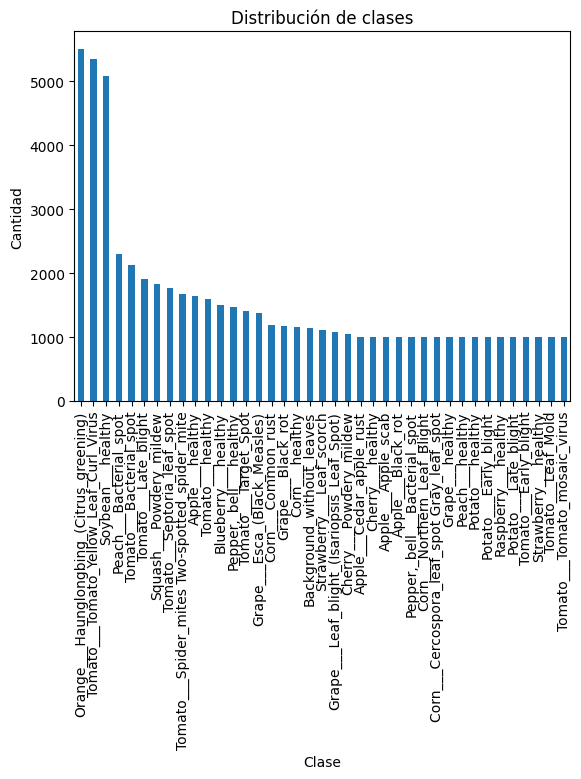


Conteo por clase:
label
Orange___Haunglongbing_(Citrus_greening)         5507
Tomato___Tomato_Yellow_Leaf_Curl_Virus           5357
Soybean___healthy                                5090
Peach___Bacterial_spot                           2297
Tomato___Bacterial_spot                          2127
Tomato___Late_blight                             1909
Squash___Powdery_mildew                          1835
Tomato___Septoria_leaf_spot                      1771
Tomato___Spider_mites Two-spotted_spider_mite    1676
Apple___healthy                                  1645
Tomato___healthy                                 1591
Blueberry___healthy                              1502
Pepper,_bell___healthy                           1478
Tomato___Target_Spot                             1404
Grape___Esca_(Black_Measles)                     1383
Corn___Common_rust                               1192
Grape___Black_rot                                1180
Corn___healthy                                   1162
Bac

,0,1,2,3,4,5,6,7,8,9,...,246,247,248,249,250,251,252,253,254,255
count,61486.000000,61486.000000,61486.000000,61486.000000,61486.000000,61486.000000,61486.000000,61486.000000,61486.000000,61486.000000,...,61486.000000,61486.000000,61486.000000,61486.000000,61486.000000,61486.000000,61486.000000,61486.000000,61486.000000,61486.000000
mean,0.102986,0.152325,0.055205,0.027155,0.021022,0.012092,0.007255,0.004910,0.003652,0.002426,...,0.001410,0.000826,0.000565,0.000360,0.000238,0.000174,0.000125,0.000100,0.000086,0.000120
std,0.195665,0.258756,0.146949,0.096543,0.092574,0.058143,0.028549,0.017435,0.013721,0.011227,...,0.007137,0.005241,0.004233,0.003176,0.002514,0.002444,0.002783,0.003610,0.004296,0.005600
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.002911,0.002397,0.001023,0.000372,0.000120,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.012012,0.018413,0.005074,0.002232,0.001474,0.000786,0.000392,0.000155,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.087520,0.154870,0.021228,0.008505,0.006734,0.004895,0.003404,0.001938,0.001399,0.000680,...,0.000468,0.000188,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,0.999542,0.995308,0.980799,0.951269,0.956807,0.917604,0.700800,0.519519,0.566913,0.623363,...,0.333948,0.194115,0.183491,0.191720,0.164623,0.225416,0.328158,0.459328,0.472627,0.895417


In [ ]:
# Distribución de clases
plt.figure()
df['label'].value_counts().plot(kind='bar')
plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()

# Ver desbalance
print("\nConteo por clase:")
print(df['label'].value_counts())

# Estadísticas básicas
print("\nEstadísticas:")
df.describe()


## 5. Preprocesamiento y división de dataset

In [ ]:
# Separar features y labels
X = df.drop('label', axis=1)
y = df['label']

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (49188, 256)
Test: (12298, 256)


## 6. Entrenamiento con o sin RAPIDS

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

if USE_GPU:
    # Convertir a cudf
    X_train_gpu = cudf.DataFrame(X_train)
    y_train_gpu = cudf.Series(y_train.astype('category').cat.codes)

    from cuml.neighbors import KNeighborsClassifier as cuKNN
    model = cuKNN(n_neighbors=5)
    model.fit(X_train_gpu, y_train_gpu)
else:
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_train, y_train)

## 7. Test y predicción

In [ ]:
if USE_GPU:
    X_test_gpu = cudf.DataFrame(X_test)
    preds = model.predict(X_test_gpu).to_pandas()
else:
    preds = model.predict(X_test)

## 8. Evaluación


📊 Classification Report:

                                               precision    recall  f1-score   support

                           Apple___Apple_scab       0.75      0.56      0.64       200
                            Apple___Black_rot       0.62      0.82      0.71       200
                     Apple___Cedar_apple_rust       0.75      0.84      0.79       200
                              Apple___healthy       0.87      0.74      0.80       329
                    Background_without_leaves       0.95      0.83      0.89       229
                          Blueberry___healthy       0.75      0.94      0.84       300
                      Cherry___Powdery_mildew       0.73      0.59      0.65       210
                             Cherry___healthy       0.66      0.73      0.69       200
   Corn___Cercospora_leaf_spot Gray_leaf_spot       0.74      0.81      0.78       200
                           Corn___Common_rust       0.94      0.98      0.96       238
               

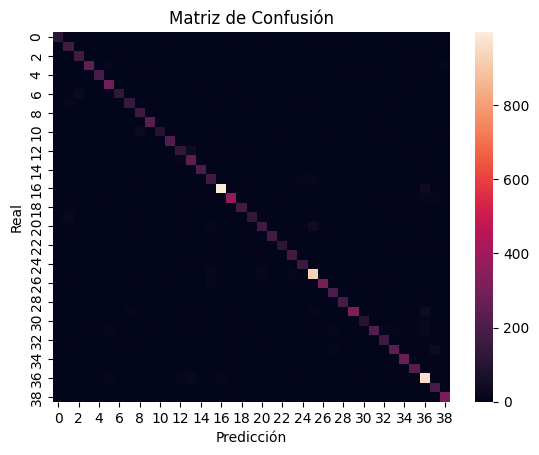

In [ ]:
category_map = dict(enumerate(y_train.astype('category').cat.categories))
preds_labels = preds.map(category_map)

print("\n📊 Classification Report:\n")
print(classification_report(y_test, preds_labels))

# Matriz de confusión
cm = confusion_matrix(y_test, preds_labels)

plt.figure()
sns.heatmap(cm, annot=False)
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

## 9. Análisis de errores

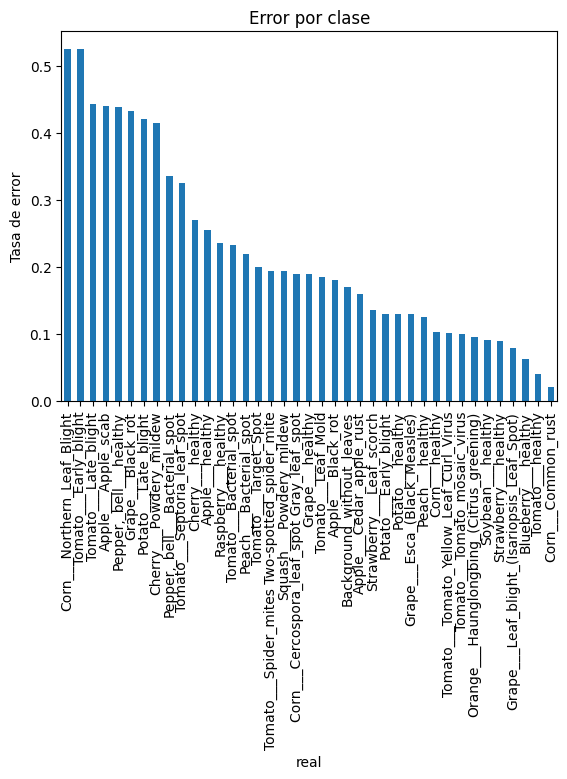


Clases con más error:
real
Corn___Northern_Leaf_Blight      0.525000
Tomato___Early_blight            0.525000
Tomato___Late_blight             0.442408
Apple___Apple_scab               0.440000
Pepper,_bell___healthy           0.439189
Grape___Black_rot                0.432203
Potato___Late_blight             0.420000
Cherry___Powdery_mildew          0.414286
Pepper,_bell___Bacterial_spot    0.335000
Tomato___Septoria_leaf_spot      0.324859
Name: error, dtype: float64


In [ ]:
preds_labels.index = y_test.index
# Errores por clase
errors = (y_test != preds_labels)
error_df = pd.DataFrame({
    'real': y_test,
    'pred': preds_labels,
    'error': errors
})

error_rate = error_df.groupby('real')['error'].mean().sort_values(ascending=False)

plt.figure()
error_rate.plot(kind='bar')
plt.title("Error por clase")
plt.ylabel("Tasa de error")
plt.show()

print("\nClases con más error:")
print(error_rate.head(10))

## 10. Clustering Visual

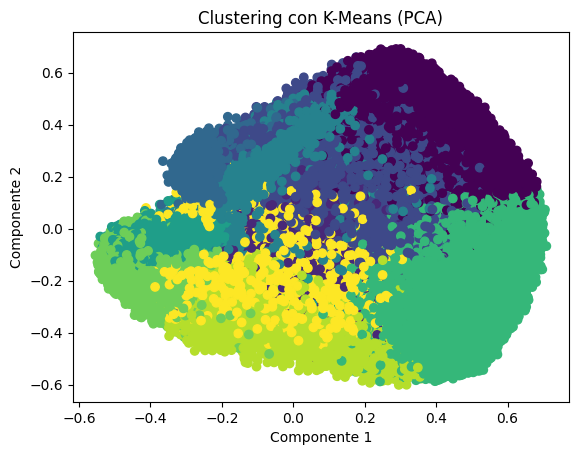

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Reducir dimensionalidad para visualización
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Aplicar K-Means
kmeans = KMeans(n_clusters=10, random_state=42)
clusters = kmeans.fit_predict(X)

# Visualización
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.title("Clustering con K-Means (PCA)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()

## 11. Análisis de Clus

In [ ]:
cluster_df = pd.DataFrame({
    'cluster': clusters,
    'label': y
})

# Ver distribución de clases por cluster
cluster_analysis = pd.crosstab(cluster_df['cluster'], cluster_df['label'])

print("Distribución de clases por cluster:")
print(cluster_analysis)

Distribución de clases por cluster:
label    Apple___Apple_scab  Apple___Black_rot  Apple___Cedar_apple_rust  \
cluster                                                                    
0                         0                 20                       114   
1                       241                 17                        24   
2                         0                  0                       563   
3                         3                  0                        29   
4                       203                  1                        74   
5                       330                365                         0   
6                         5                378                        85   
7                       169                204                         3   
8                        36                 15                        86   
9                        13                  0                        22   

label    Apple___healthy  Background_without_leaves

In [ ]:
print("Resumen:")
print(f"Accuracy aproximado: {np.mean(preds_labels == y_test):.4f}")
print("El clustering permite observar si las clases son separables visualmente.")
print("Clusters mezclados indican similitud entre enfermedades.")

Resumen:
Accuracy aproximado: 0.8036
El clustering permite observar si las clases son separables visualmente.
Clusters mezclados indican similitud entre enfermedades.
